In [126]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [159]:
# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

In [160]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths)

In [161]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [162]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [163]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_flight_sum)

In [164]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [165]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [166]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [167]:
filtered_nc[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_nc[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [168]:
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))
    dsf["Times"] = (("time",), datetime_values)

    return dsf

In [169]:
def dataset_neph(file_path_neph):

    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds_neph

In [170]:
ds_neph = dataset_neph(filtered_neph[0])

In [171]:
ds_wet_neph= xr.open_dataset(filtered_nc[0])
minlon, maxlon, minlat, maxlat = -70, -55, -16, -2  # Example box 1

In [172]:
ds_wet_neph['TDEW_GE']
ds_wet_neph['TAT_DI_R']

<xarray.DataArray 'TAT_DI_R' (data_point: 25820, sps32: 32)> Size: 3MB
[826240 values with dtype=float32]
Dimensions without coordinates: data_point, sps32
Attributes:
    long_name:      True air temperature from the Rosemount deiced temperatur...
    units:          degK          
    frequency:      32
    Number:         520
    standard_name:  air_temperature

In [173]:
dry_neph_time = ds_neph["datetime"].values  # Original timestamps from new dataset
wet_neph_time = ds_wet_neph["Time"].values  # Original timestamps from new dataset
common_times = np.intersect1d(wet_neph_time, dry_neph_time)

# Create a boolean mask as an Xarray DataArray
mask_dry = xr.DataArray(np.isin(dry_neph_time, common_times), dims=["time"])
mask_wet = xr.DataArray(np.isin(wet_neph_time, common_times), dims=["data_point"])

# Apply the mask to filter ds_psap
ds_dry_matched = ds_neph.where(mask_dry, drop=True)
ds_wet_matched = ds_wet_neph.where(mask_wet, drop=True)

In [174]:
ds_wet_matched['TDEW_GE'].shape  # Dew point temperature in Kelvin

(20998, 4)

In [175]:

# Extract the dew point and time
T_dew_K = ds_wet_matched['TDEW_GE']  # Dew point temperature in Kelvin
time = ds_wet_matched['Time']  # Time variable

# Convert 'Time' to a pandas datetime index for resampling
# Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
time_index = pd.to_datetime(time.values, unit='s')
print(T_dew_K.shape)

T_dew_flat = T_dew_K.values.flatten()
time_flat = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)


# Create a pandas DataFrame for easier resampling
df = pd.DataFrame({'Time': time_flat, 'TDEW_GE': T_dew_flat})

# Resample the data by 1 minute and calculate the mean for each interval
df_resampled = df.resample('1min', on='Time').mean()

# Convert the resampled dew point temperature back to an xarray
T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                               dims=['time'], 
                               coords={'time': df_resampled.index.values})
#T_dew_resampled

(20998, 4)


In [176]:
# Extract the True air temperature and time
T_air_K = ds_wet_matched['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
time = ds_wet_matched['Time']  # Time variable with shape (20998)

# Step 1: Convert Time to pandas datetime
# We'll assume 'Time' is in seconds and create a time index that repeats each second for 32Hz measurements.
time_index = pd.to_datetime(time.values, unit='s')

# Step 2: Create a pandas DataFrame for resampling
# Flatten the TAT_DI_R array to make it 1D for DataFrame construction
T_air_flat = T_air_K.values.flatten()
time_flat = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)

# Create a DataFrame with the flattened arrays
df = pd.DataFrame({'Time': time_flat, 'TAT_DI_R': T_air_flat})

# Step 3: Resample the data by 1 minute and compute the mean for each time interval
df_resampled = df.resample('1min', on='Time').mean()

# Step 4: Convert back to xarray
T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                               dims=['time'], 
                               coords={'time': df_resampled.index.values})

In [177]:
# Convert from Kelvin to Celsius
T_dew_resampled_C = T_dew_resampled - 273.15

# Convert from Kelvin to Celsius
T_air_resampled_C = T_air_resampled - 273.15

# Convert to Celsius
T_dew_C = T_dew_resampled_C
T_air_C = T_air_resampled_C

# Calculate relative humidity using the Magnus formula
RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
            np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

# Optional: Add RH to the dataset
#RH

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


In [178]:
def relative_hum_calc(ds_dry_neph,ds_wet_neph):
    
    dry_neph_time = ds_neph["datetime"].values  # Original timestamps from new dataset
    wet_neph_time = ds_wet_neph["Time"].values  # Original timestamps from new dataset
    common_times = np.intersect1d(wet_neph_time, dry_neph_time)

    # Create a boolean mask as an Xarray DataArray
    mask_dry = xr.DataArray(np.isin(dry_neph_time, common_times), dims=["time"])
    mask_wet = xr.DataArray(np.isin(wet_neph_time, common_times), dims=["data_point"])

    # Apply the mask to filter ds_psap
    ds_dry_matched = ds_neph.where(mask_dry, drop=True)
    ds_wet_matched = ds_wet_neph.where(mask_wet, drop=True)


    
    # Extract the dew point and time
    T_dew_K = ds_wet_matched['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_wet_matched['Time']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_wet_matched['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))


    # Extract the time and scattering coefficient
    times = ds_dry_matched['Times']
    scattering = ds_dry_matched['TSC_BLUU']
    
    # Convert time to datetime (assuming seconds since epoch or similar)
    times_dt = pd.to_datetime(times.values, unit='s')
    
    # Create a DataFrame for easy resampling
    df_scattering = pd.DataFrame({
        'Time': times_dt,
        'TSC_BLUU': scattering.values
    })
    
    # Resample by 1 minute
    df_scattering_resampled = df_scattering.resample('1min', on='Time').mean()
    
    # Convert back to xarray
    scattering_resampled = xr.DataArray(
        df_scattering_resampled['TSC_BLUU'].values,
        dims=['time'],
        coords={'time': df_scattering_resampled.index.values},
        name='TSC_BLUU'
    )
    return scattering_resampled, RH

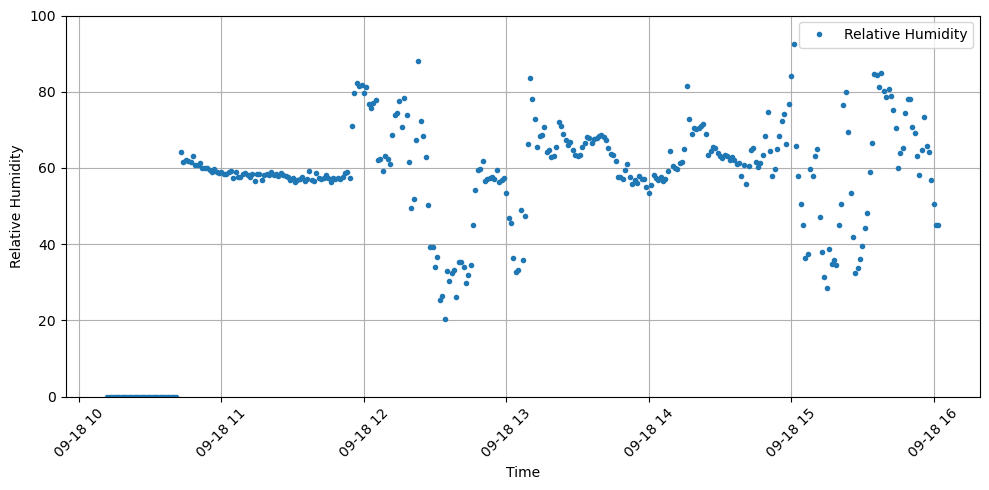

In [179]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
#plt.plot(ds_wet_matched['Time'], ds_wet_matched['TSC_BLUU'],label='Wet Nephelometer', marker='.',linewidth=0)
plt.plot(RH['time'], RH,label='Relative Humidity', marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Relative Humidity')
plt.ylim(0,100)
#plt.xlim(ds_wet_matched['Time'],ds_wet_matched['Time'])
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

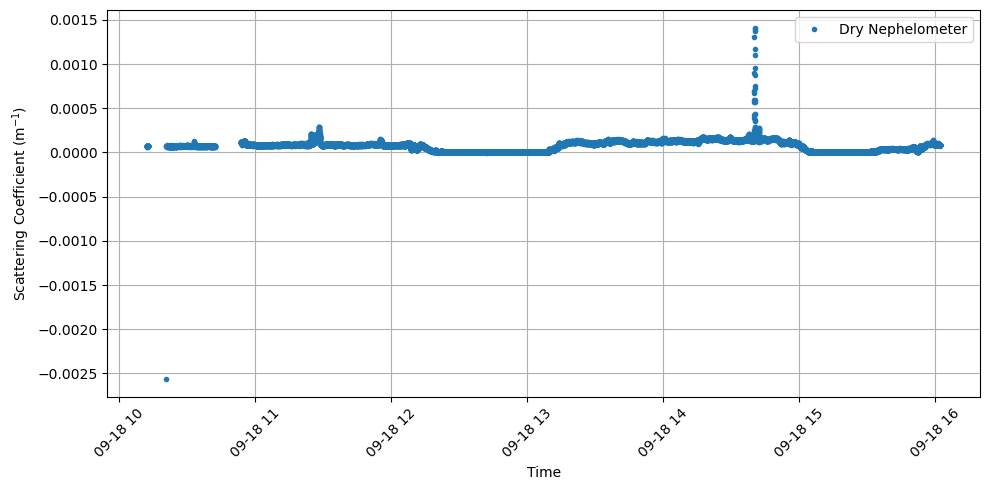

In [180]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
#plt.plot(ds_wet_matched['Time'], ds_wet_matched['TSC_BLUU'],label='Wet Nephelometer', marker='.',linewidth=0)
plt.plot(ds_dry_matched['Times'], ds_dry_matched['TSC_BLUU'],label='Dry Nephelometer', marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
#plt.ylim(0,np.max(ds_dry_matched['TSC_BLUU'])*1.1)
#plt.xlim(ds_wet_matched['Time'],ds_wet_matched['Time'])
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [181]:
# Extract the time and scattering coefficient
times = ds_dry_matched['Times']
scattering = ds_dry_matched['TSC_BLUU']

# Convert time to datetime (assuming seconds since epoch or similar)
times_dt = pd.to_datetime(times.values, unit='s')

# Create a DataFrame for easy resampling
df_scattering = pd.DataFrame({
    'Time': times_dt,
    'TSC_BLUU': scattering.values
})

# Resample by 1 minute
df_scattering_resampled = df_scattering.resample('1min', on='Time').mean()

# Convert back to xarray
scattering_resampled = xr.DataArray(
    df_scattering_resampled['TSC_BLUU'].values,
    dims=['time'],
    coords={'time': df_scattering_resampled.index.values},
    name='TSC_BLUU'
)

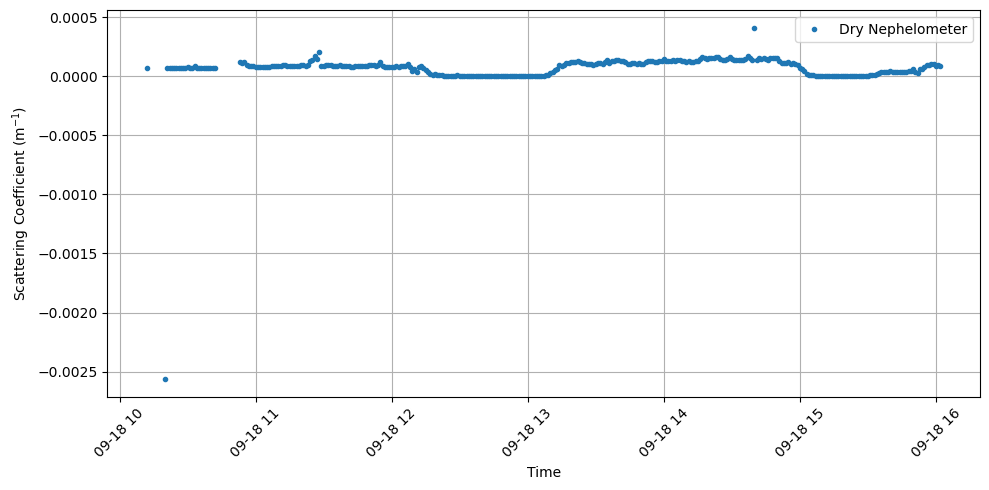

In [182]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
#plt.plot(ds_wet_matched['Time'], ds_wet_matched['TSC_BLUU'],label='Wet Nephelometer', marker='.',linewidth=0)
plt.plot(scattering_resampled['time'], scattering_resampled,label='Dry Nephelometer', marker='.',linewidth=0)

plt.xlabel('Time')
plt.ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
#plt.ylim(0,np.max(ds_dry_matched['TSC_BLUU'])*1.1)
#plt.xlim(ds_wet_matched['Time'],ds_wet_matched['Time'])
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

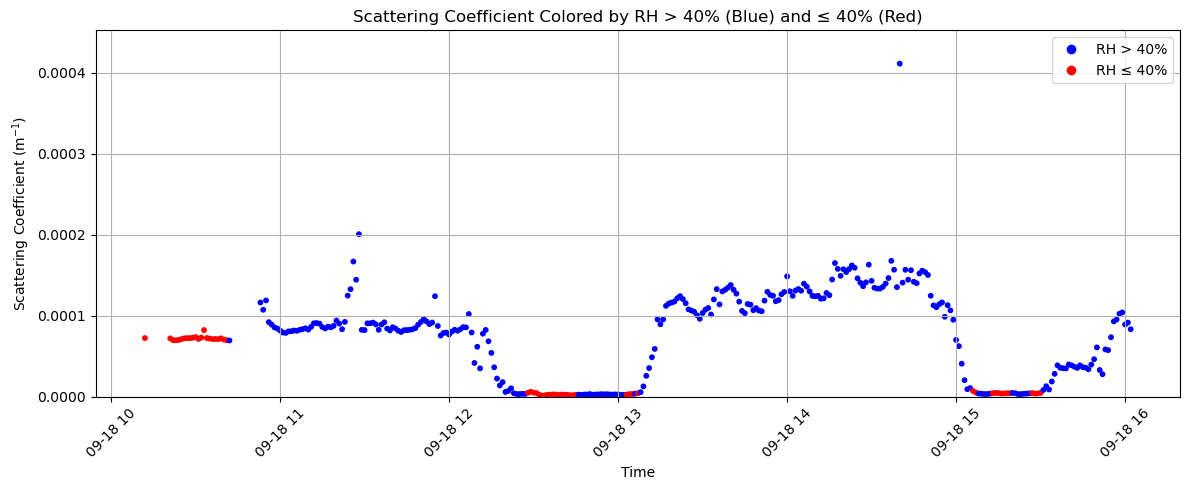

In [183]:
# Create color array based on RH threshold
colors = np.where(RH > 40, 'blue', 'red')

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(scattering_resampled['time'], scattering_resampled, c=colors, label='Scattering (1-min avg)', s=10)

plt.xlabel('Time')
plt.ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
plt.title('Scattering Coefficient Colored by RH > 40% (Blue) and ≤ 40% (Red)')
plt.ylim(0, np.max(scattering_resampled)*1.1)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Optional legend proxy

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='RH > 40%', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='RH ≤ 40%', markerfacecolor='red', markersize=8),
]
plt.legend(handles=legend_elements)

plt.show()

In [184]:
def parse_flight_log(lines):
    extracted_data = []
    
    for line in lines[2:]:  # Skip headers
        parts = re.split(r'\s{2,}', line.strip())  # Split on 2+ spaces
        
        if len(parts) < 2:
            continue  # Skip lines with insufficient data
        
        start_time = parts[0]  # First column is always Start Time

        # Check if second column is numeric (End Time), if so, event is at index 2
        if len(parts) > 2 and parts[1].isdigit():
            event = parts[2]  # Third column is the event
        else:
            event = parts[1]  # Otherwise, second column is the event

        extracted_data.append([start_time, event])  # Append as list (not tuple)
        
    return np.array(extracted_data)  # Convert to NumPy array

In [185]:
def flight_comments_df(file_path_flight_comm):
    # Read the file
    with open(file_path_flight_comm, "r") as file:
        lines = file.readlines()
    # Process and print output
    parsed_data = parse_flight_log(lines)
    
    start_time_col = parsed_data[3:, 0]  # First column
    event_col = parsed_data[3:, 1]  # Second column

    # Create DataFrame
    df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

    
    return df_flight

In [186]:
# Read the file
with open(filtered_sum[0], "r") as file:
    lines = file.readlines()
# Process and print output
parsed_data = parse_flight_log(lines)

start_time_col = parsed_data[3:, 0]  # First column
event_col = parsed_data[3:, 1]  # Second column

# Create DataFrame
df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

# Print the DataFrame
#print(df_flight)

In [187]:
# Assuming df is your DataFrame and has columns "Start Time" and "Event"
start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]

# Print the extracted start time
print(start_up_time)

114944


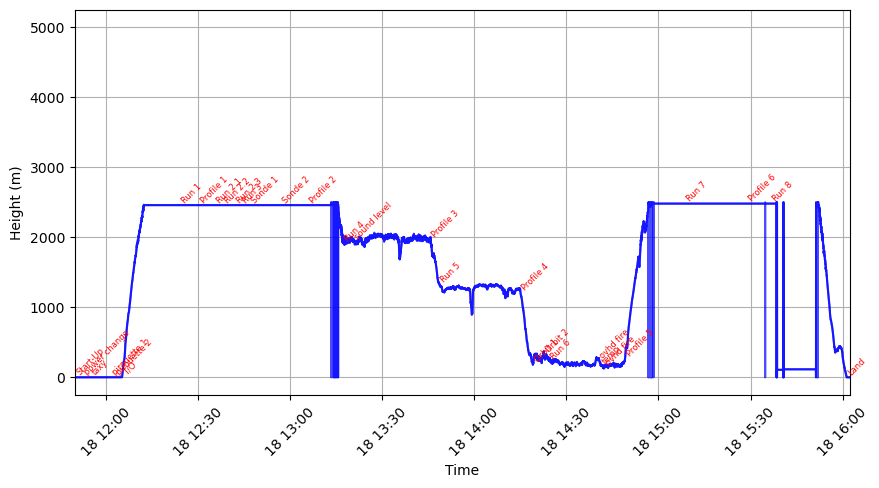

In [188]:
# Step 1: Convert 'Start Time' from HHMMSS to datetime
df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")  # Convert HHMMSS to time only
df_flight["Start Time"] = df_flight["Start Time"].apply(lambda t: pd.Timestamp("2012-09-18") + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second))

# Extract time values from the dataset (since it's a variable, not a dimension)
ds_times = ds_wet_neph["Time"].values  # Convert to NumPy array

# Step 2: Plot the height over time
plt.figure(figsize=(10, 5))

# Plot height (HGT_RADR) over time
plt.plot(ds_times, ds_wet_neph["HGT_RADR"].values, color="b", linestyle="-", alpha=0.7, label="Height")

# Step 3: Overlay event labels
for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
    # Find the closest time in the dataset
    closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))  # Index of nearest timestamp
    closest_time = ds_times[closest_idx]
    height_at_time = ds_wet_neph["HGT_RADR"].values[closest_idx][0]  # Get height value

    # Plot event text
    plt.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)


# Assuming df is your DataFrame and has columns "Start Time" and "Event"
start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]

# Set xlim to start at 11:40
plt.xlim(start_up_time, ds_times[-1])  # ds_times[-1] is the last time value

# Labels and formatting
plt.xlabel("Time")
plt.ylabel(r"Height (m)")
plt.xticks(rotation=45)
plt.grid()
#plt.legend()

# Tight layout for better plot formatting
#plt.tight_layout()

# Show the plot
plt.show()

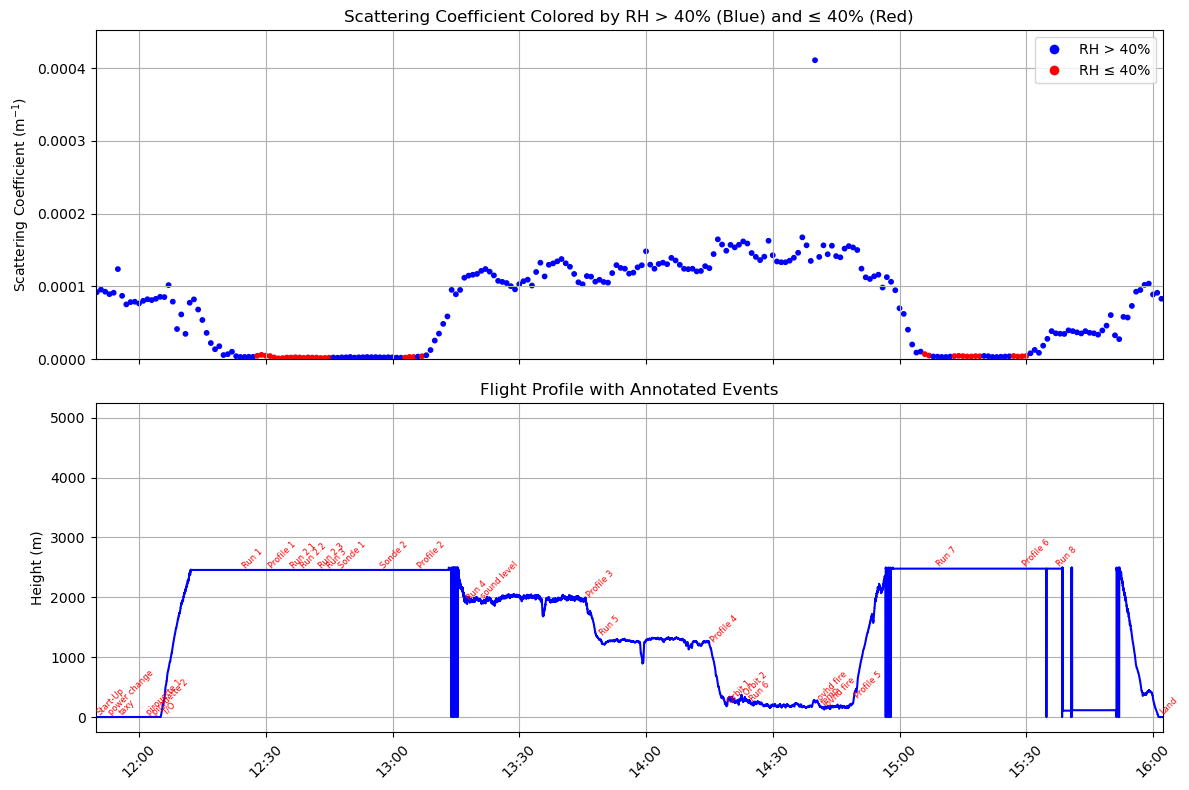

In [189]:
# Step 1: Convert 'Start Time' (HHMMSS) to full datetime for event annotations
df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")
df_flight["Start Time"] = df_flight["Start Time"].apply(
    lambda t: pd.Timestamp("2012-09-18") + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second)
)

# Step 2: Prepare scattering and RH data
colors = np.where(RH > 40, 'blue', 'red')  # Color by RH threshold

# Step 3: Prepare height and time data
ds_times = ds_wet_neph["Time"].values  # Time from dataset
height_values = ds_wet_neph["HGT_RADR"].values[:, 0]  # Assuming shape (time, sps)

# Step 4: Create the figure with 2 separate subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8), sharex=True)

# Time formatter to show HH:MM
time_formatter = mdates.DateFormatter('%H:%M')

# --- First Plot: Scattering colored by RH ---
ax1.scatter(scattering_resampled['time'], scattering_resampled.values, c=colors, s=10)
ax1.set_ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
ax1.set_ylim(0, np.nanmax(scattering_resampled.values) * 1.1)
ax1.grid(True)
ax1.legend(handles=[
    Line2D([0], [0], marker='o', color='w', label='RH > 40%', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='RH ≤ 40%', markerfacecolor='red', markersize=8),
], loc='upper right')
ax1.set_title('Scattering Coefficient Colored by RH > 40% (Blue) and ≤ 40% (Red)')
# --- Second Plot: Height over time with event labels ---
ax2.plot(ds_times, height_values, color="b", label="Height")

for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
    closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))
    closest_time = ds_times[closest_idx]
    height_at_time = height_values[closest_idx]
    ax2.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)

ax2.set_ylabel("Height (m)")
ax2.set_title("Flight Profile with Annotated Events")
ax2.grid(True)

# Set time format on x-axis
ax2.xaxis.set_major_formatter(time_formatter)

# Set x-axis limits starting from "Start-Up" event
if "Start-Up" in df_flight["Event"].values:
    start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]
    ax2.set_xlim(start_up_time, ds_times[-1])

# Rotate x-axis labels
plt.xticks(rotation=45)

# Layout
plt.tight_layout()
plt.show()

In [190]:
def plot_flight_data_v4(flight_number,flight_date,
                     area_time, data_mass_concentration, 
                     filtered_ds_psap_aux, Mass_absortion_eff, 
                     filtered_ds_psap_aux_PSAP_LIN, 
                     ds_neph_datetime, ds_neph_TSC_BLUU,
                     ds_psap, df_flight, minlon, maxlon, minlat, maxlat):
    
    fig = plt.figure(figsize=(14, 15))

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))


    # Step 1: Convert 'Start Time' from HHMMSS to datetime
    df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")  # Convert HHMMSS to time only
    df_flight["Start Time"] = df_flight["Start Time"].apply(lambda t: pd.Timestamp(flight_date) + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second))
    
    start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]
    # Define plot positions
    # Define updated plot positions for 5 subplots
    # Adjusted positions
    positions = {
        "stacked": [0.06, 0.74, 0.4, 0.2],         # Top-left
        "abs_coef": [0.06, 0.52, 0.4, 0.2],         # Middle-left
        "scatter_coef": [0.06, 0.30, 0.4, 0.2],        # Lower-left
        "height_time": [0.06, 0.08, 0.4, 0.2],    # Bottom-left
        "map": [0.52, 0.45, 0.42, 0.34],           # Top-right
    }


    # First plot - Stacked Area Plot
    ax1 = fig.add_axes(positions["stacked"])
    labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
    colors = ["black", "red", "orange", "green", "navy", "cyan"]
    ax1.stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)
    #ax1.set_xlabel("Time")
    ax1.set_ylabel("Mass Concentration (µg/m³)")
    #print(area_time[0])
    ax1.set_title(f"Flight {flight_number} - Date: {flight_date}")
    ax1.legend(loc="upper left")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()
    ax1.tick_params(labelbottom=False)
    ax1.set_xlim(start_up_time, ds_psap['Time'].values[-1])

    # Second plot - Mass Absorption Efficiency over Time
    #ax2 = fig.add_axes(positions["abs_eff"])
    #ax2.plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.', linewidth=0)
    #ax2.set_xlabel("Datetime")
    #ax2.set_ylabel("Mass Absorption Efficiency (m²/g)")
    #ax2.set_title(f"Flight {flight_number} - Mass Absorption Efficiency\nDate: {flight_date}")
    #ax2.yaxis.set_major_formatter(formatter)
    #ax2.tick_params(axis='x', rotation=45)
    #ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    #ax2.grid()

    # Third plot - Absorption Coefficient
    ax2 = fig.add_axes(positions["abs_coef"])
    ax2.plot(filtered_ds_psap_aux['Time'], filtered_ds_psap_aux_PSAP_LIN, color="r", marker='.', linewidth=0)
    #ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
    #ax2.set_title(f"Flight {flight_number} - Absorption Coefficient")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()
    ax2.tick_params(labelbottom=False)
    ax2.set_xlim(start_up_time, ds_psap['Time'].values[-1])

    # Fourth plot - Blue Scattering Coefficient
    ax4 = fig.add_axes(positions["scatter_coef"])
    ax4.plot(ds_neph_datetime, ds_neph_TSC_BLUU)
    #ax4.set_xlabel("Time")
    ax4.set_ylabel(r'Blue Scattering Coefficient ($\mathrm{m^{-1}}$)')
    #ax4.set_title(f"Flight {flight_number} - Blue Scattering Coefficient\nDate: {flight_date}")
    ax4.set_ylim(0, np.max(ds_neph_TSC_BLUU) * 1.1)
    ax4.yaxis.set_major_formatter(formatter)
    ax4.tick_params(axis='x', rotation=45)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax4.grid()
    ax4.tick_params(labelbottom=False)
    ax4.set_xlim(start_up_time, ds_psap['Time'].values[-1])

    # Fifth plot - Flight Track Map (Cartopy)
    ax5 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    #ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    ax5.coastlines()
    ax5.add_feature(cfeature.BORDERS, linestyle=':')
    ax5.add_feature(cfeature.LAND)
    ax5.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    gl = ax5.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    ax5.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    ax5.scatter(lon_filtered, lat_filtered, s=1, transform=ccrs.PlateCarree())
    ax5.set_title(f"Flight {flight_number} - Flight Track")


    # Sixth plot - Height over Time with Event Labels
        # Sixth plot - Height over Time with Event Labels
    #valid_height_mask = ds_psap["HGT_RADR_FLAG"] == 0
    #ds_psap_hight_valid = ds_psap.where(valid_height_mask, drop=False)

    ax6 = fig.add_axes(positions["height_time"])
    #ax6.plot(ds_psap['Time'].values, ds_psap['HGT_RADR'].values, color="b", linestyle="-", alpha=0.7, label="Height Altimeter")
    ax6.plot(ds_psap['Time'].values, ds_psap['GPS_ALT'].values, color="g", linestyle="-", alpha=0.7, label="Height GPS")
    for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
        closest_idx = np.argmin(np.abs(ds_psap['Time'].values - np.datetime64(event_time)))
        closest_time = ds_psap['Time'].values[closest_idx]
        height_at_time = ds_psap['GPS_ALT'].values[closest_idx][0]
        ax6.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)
    
    #print(start_up_time)
    ax6.set_xlim(start_up_time, ds_psap['Time'].values[-1])
    ax6.set_xlabel("Time")
    ax6.set_ylablel("Height (m)")
    ax6.tick_params(axis='x', rotation=45)
    ax6.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax6.grid()
    #ax6.set_title(f"Flight {flight_number} - Height over Time\nDate: {flight_date}")

    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./Flights_plots/flight_{flight_number}_v4.png', dpi=300)
    print(f"Figure saved as flight_{flight_number}_v4.png")
    #plt.show()

    return

In [191]:
def plot_neph_data_v1(flight_number,flight_date,
                     scattering_resampled, RH,
                     ds_wet_neph, df_flight):

    # Step 1: Convert 'Start Time' (HHMMSS) to full datetime for event annotations
    df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")
    df_flight["Start Time"] = df_flight["Start Time"].apply(
        lambda t: pd.Timestamp(str(flight_date)) + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second)
    )
    start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]
    
    # Step 2: Prepare scattering and RH data
    colors = np.where(RH > 40, 'blue', 'red')  # Color by RH threshold
    
    # Step 3: Prepare height and time data
    ds_times = ds_wet_neph["Time"].values  # Time from dataset
    height_values = ds_wet_neph["HGT_RADR"].values[:, 0]  # Assuming shape (time, sps)
    
    # Step 4: Create the figure with 2 separate subplots
    fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8), sharex=True)

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    
    # Time formatter to show HH:MM
    time_formatter = mdates.DateFormatter('%H:%M')
    
    # --- First Plot: Scattering colored by RH ---
    ax1.scatter(scattering_resampled['time'], scattering_resampled.values, c=colors, s=10)
    ax1.set_ylabel(r'Scattering Coefficient ($\mathrm{m^{-1}}$)')
    ax1.set_ylim(0, np.nanmax(scattering_resampled.values) * 1.1)
    ax1.yaxis.set_major_formatter(formatter)
    ax1.grid(True)
    ax1.legend(handles=[
        Line2D([0], [0], marker='o', color='w', label='RH > 40%', markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='RH ≤ 40%', markerfacecolor='red', markersize=8),
    ], loc='upper right')
    #ax1.set_title('Scattering Coefficient Colored by RH > 40% (Blue) and ≤ 40% (Red)')
    ax1.set_title(f"Flight {flight_number} - Date: {flight_date}\nScattering Coefficient Colored by RH > 40% (Blue) and ≤ 40% (Red)")
    # --- Second Plot: Height over time with event labels ---
    ax2.plot(ds_times, height_values, color="b", label="Height")
    
    for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
        closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))
        closest_time = ds_times[closest_idx]
        height_at_time = height_values[closest_idx]
        ax2.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)
    
    ax2.set_ylabel("Height (m)")
    #ax2.set_title("Flight Profile with Annotated Events")
    # Right-side title using a twin axis
    ax2_right = ax2.twinx()  # Create a twin y-axis sharing the same x-axis
    ax2_right.set_ylabel("Flight Profile with Annotated Events", rotation=90, labelpad=30)
    ax2_right.yaxis.set_label_position("right")
    ax2_right.tick_params(right=False, labelright=False)  # Hide ticks and labels
    ax2.grid(True)
    
    # Set time format on x-axis
    ax2.xaxis.set_major_formatter(time_formatter)
    ax2.set_xlim(start_up_time, ds_times[-1])
    
    # Rotate x-axis labels
    plt.xticks(rotation=45)
    
    # Layout
    plt.savefig(f'./Plots_Neph/Neph_{flight_number}_v1.png', dpi=300)
    print(f"Figure saved as Neph_{flight_number}_v1.png")
    #plt.show()
    return

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


Figure saved as Neph_b734_v1.png


/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


Figure saved as Neph_b737_v1.png


/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


...

Figure saved as Neph_b744_v1.png
Figure saved as Neph_b745_v1.png
Figure saved as Neph_b746_v1.png


/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


Figure saved as Neph_b747_v1.png
Figure saved as Neph_b748_v1.png


/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


Figure saved as Neph_b749_v1.png
Figure saved as Neph_b750_v1.png


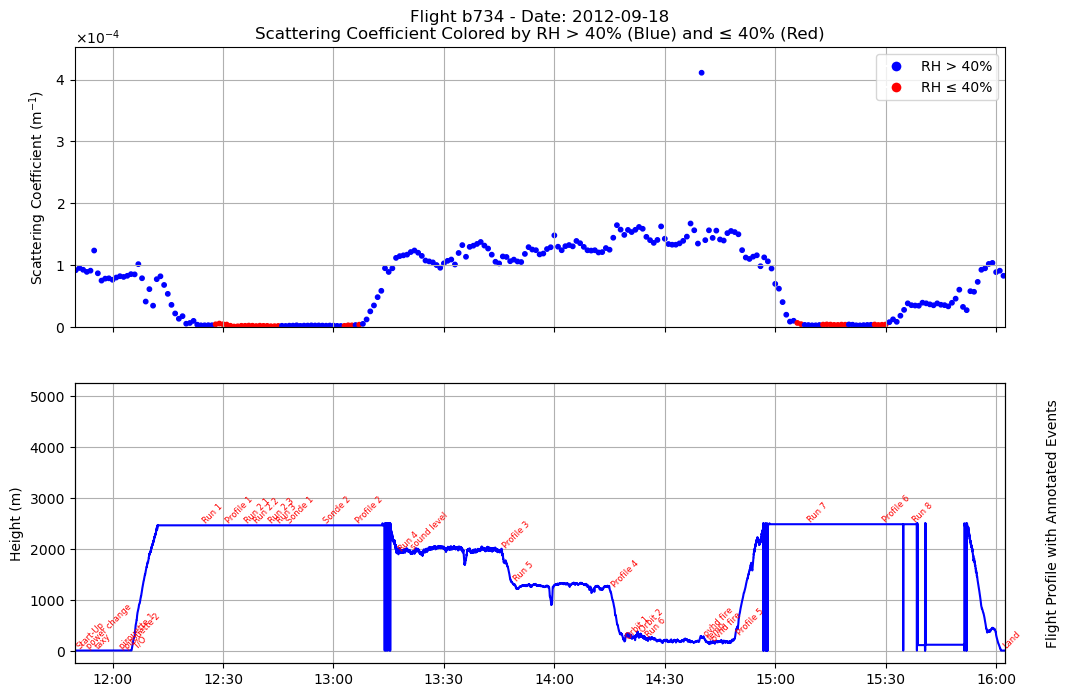

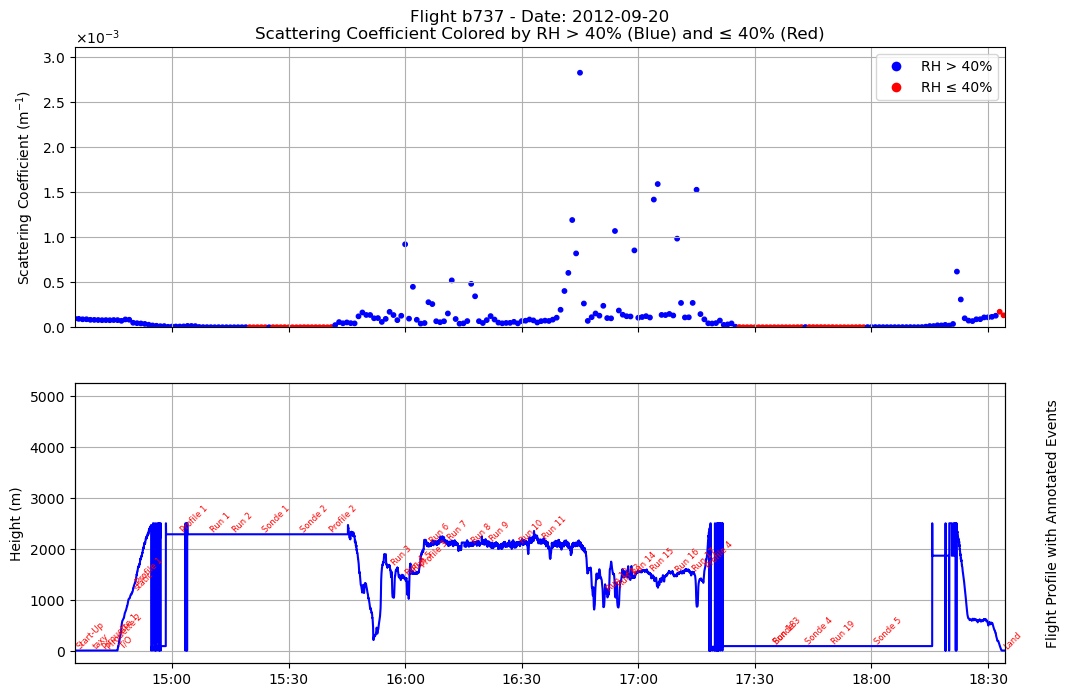

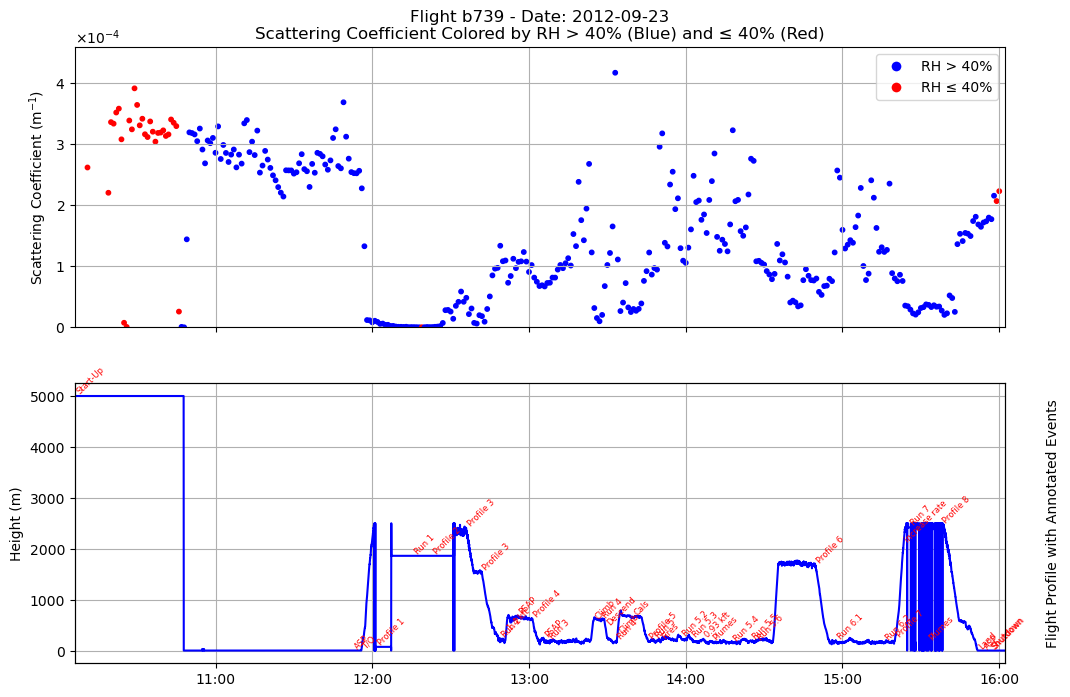

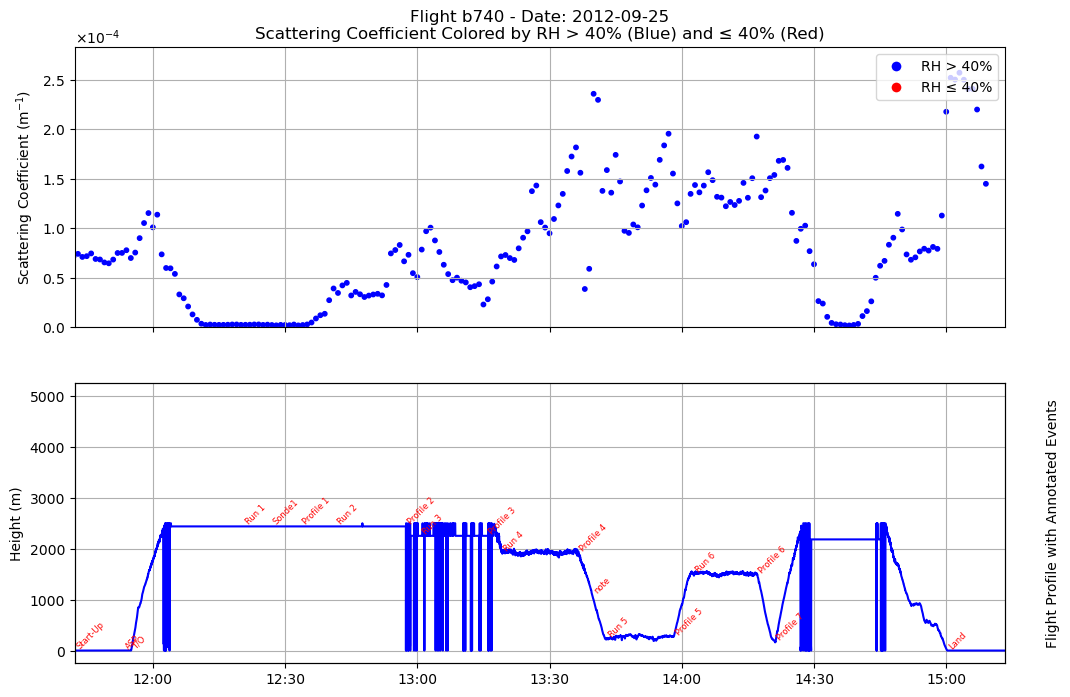

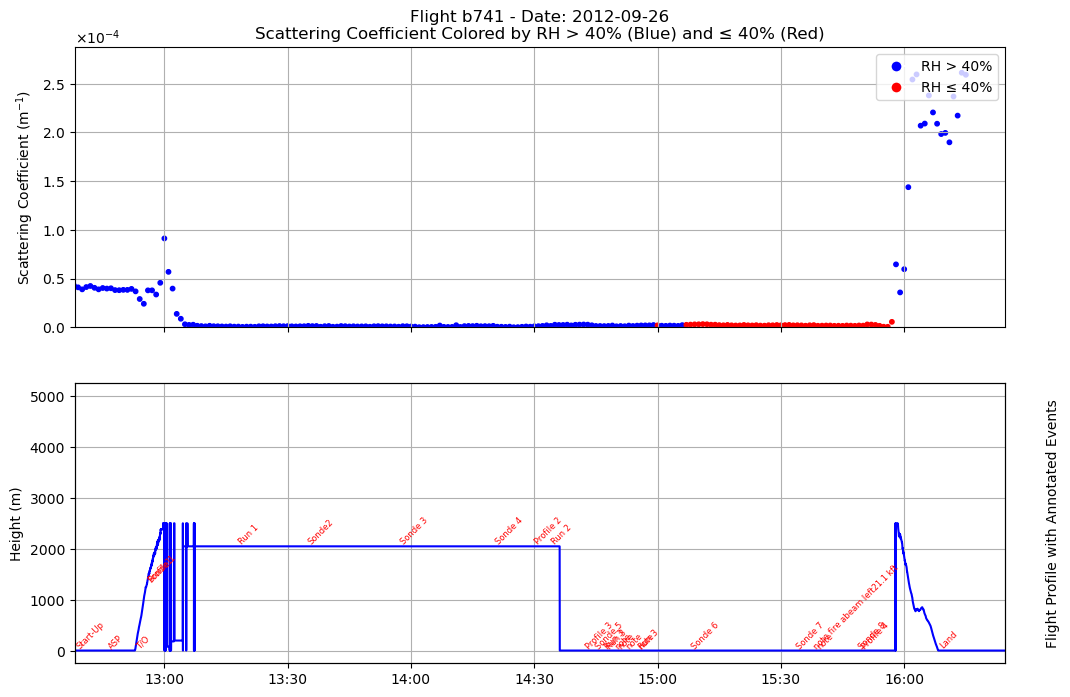

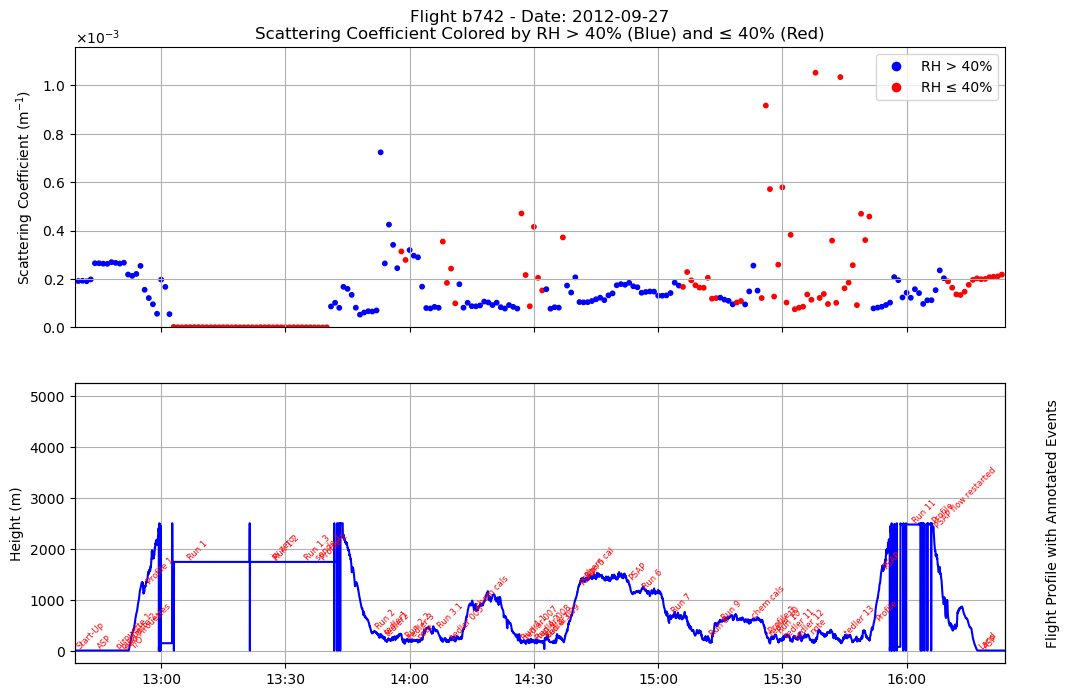

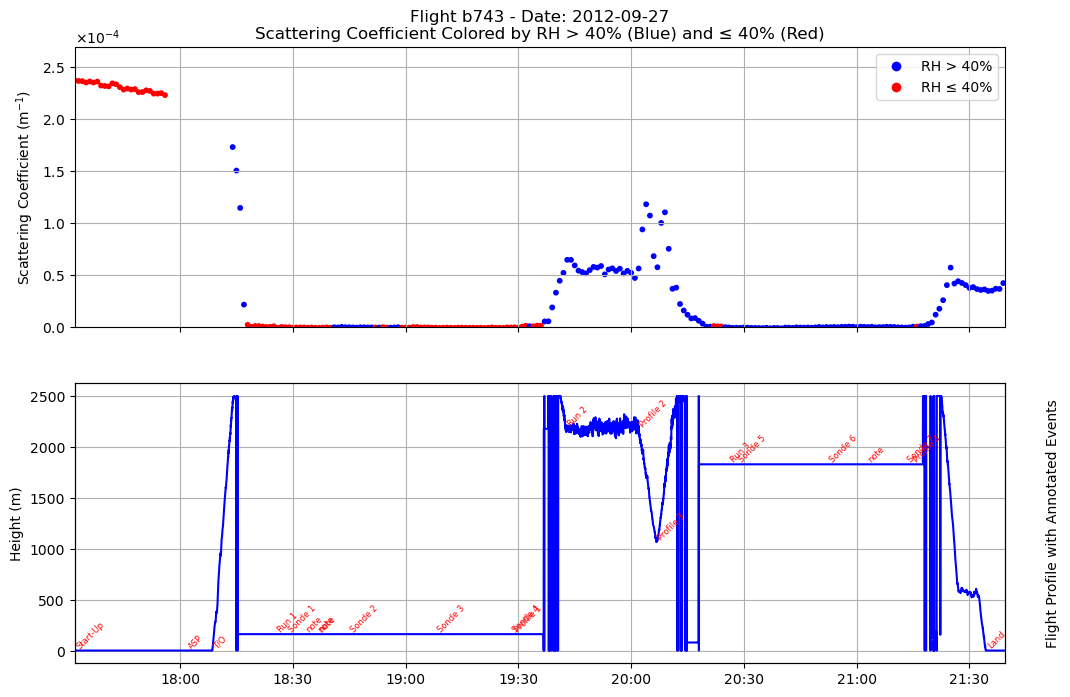

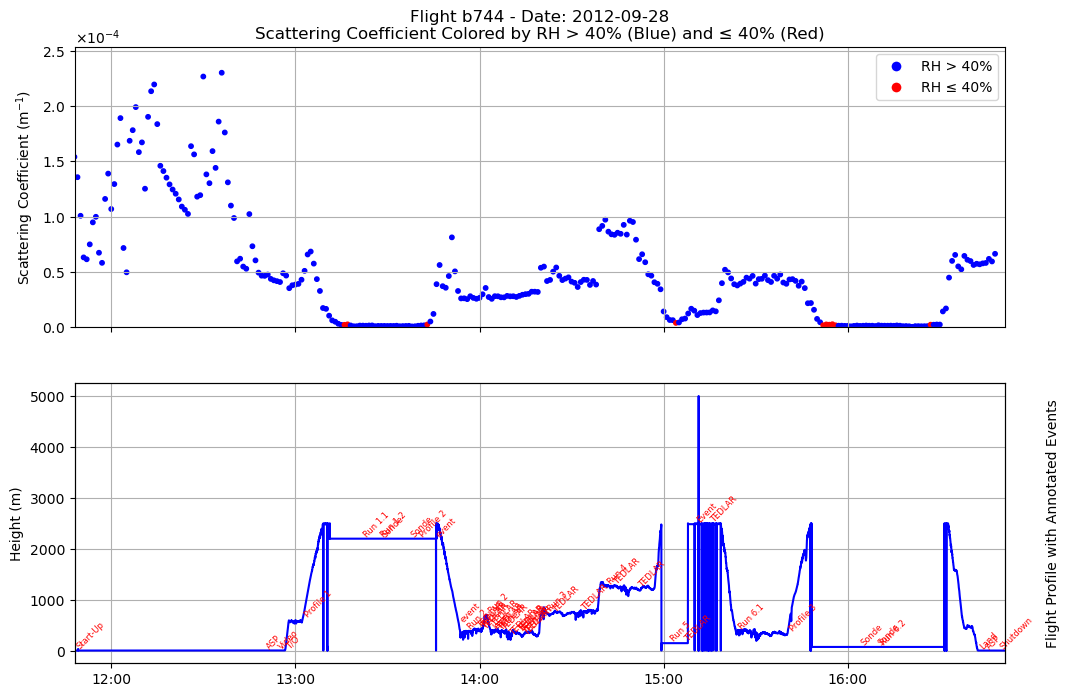

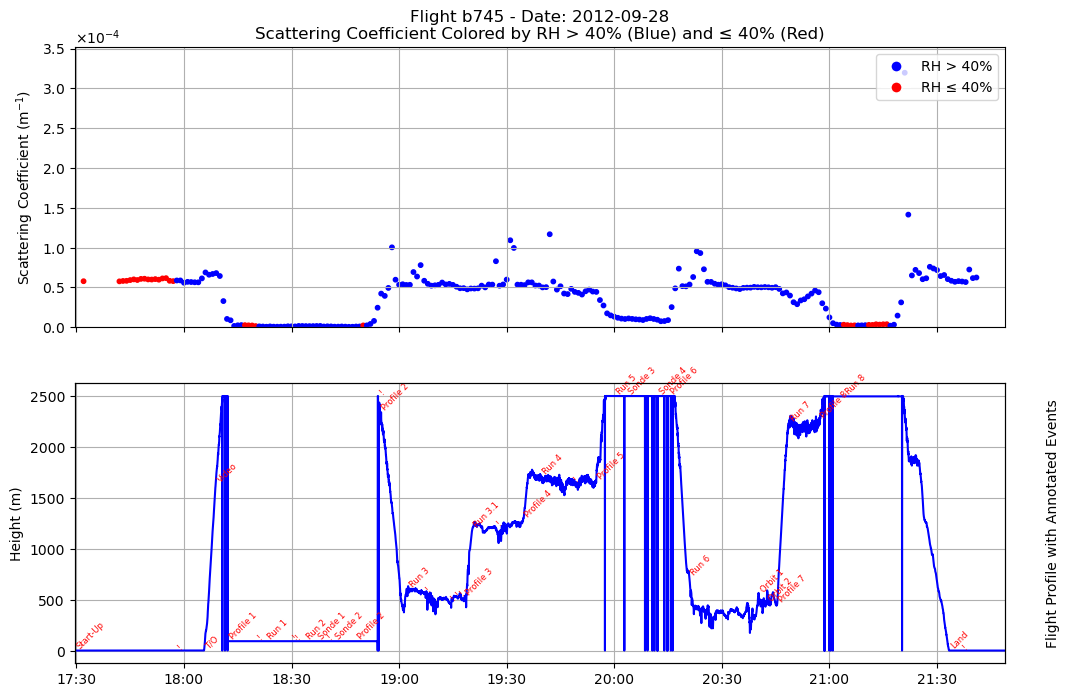

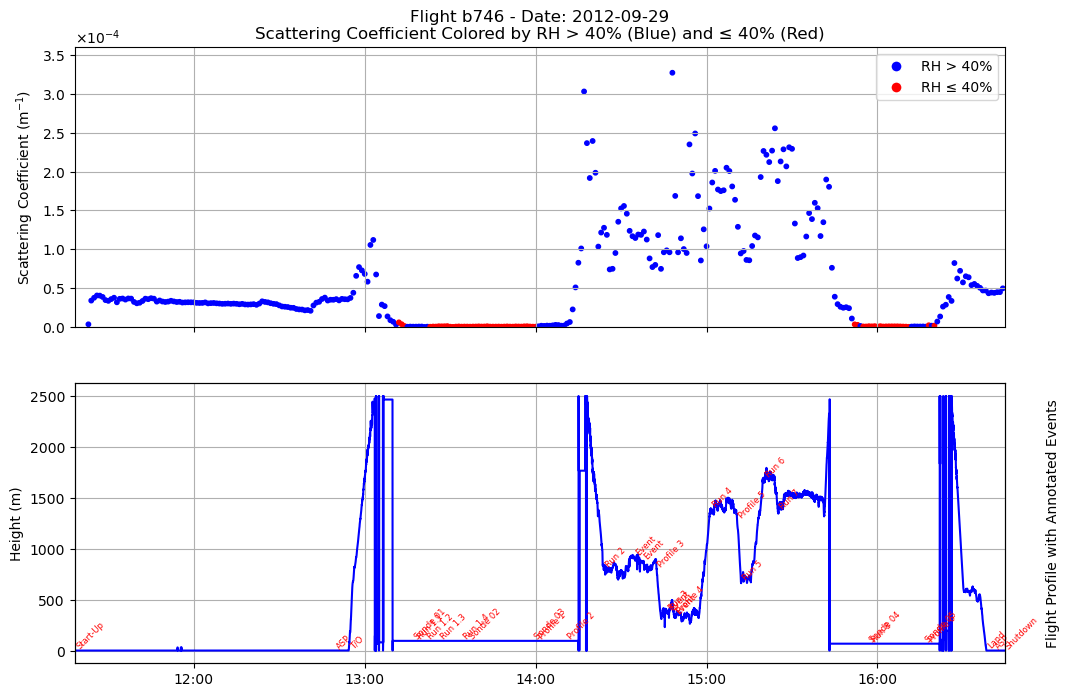

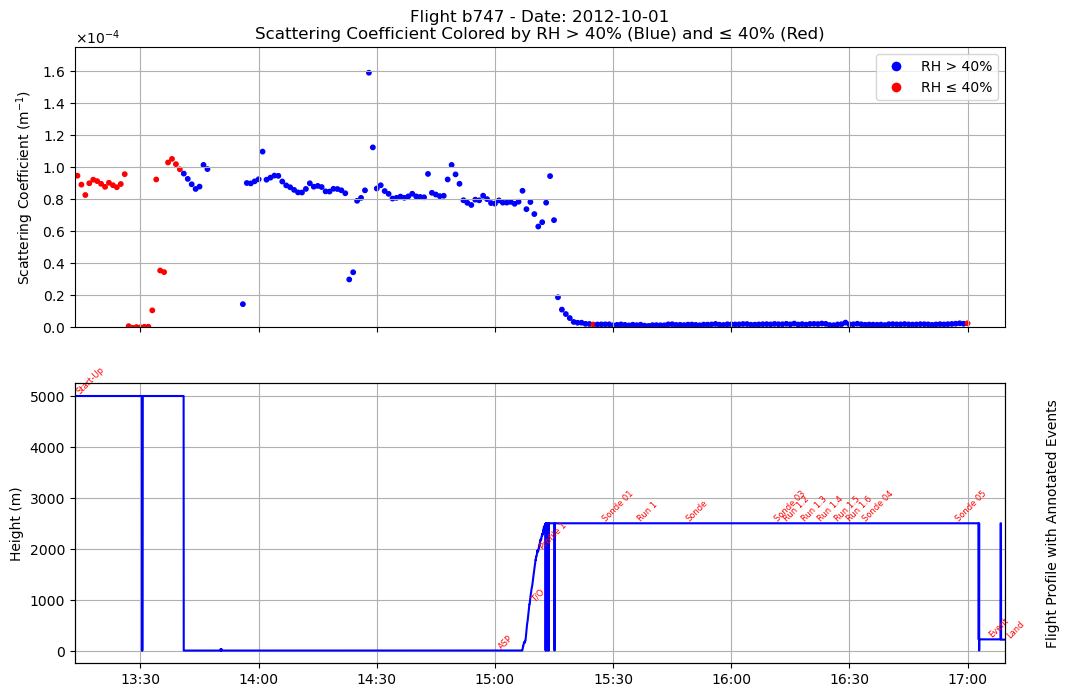

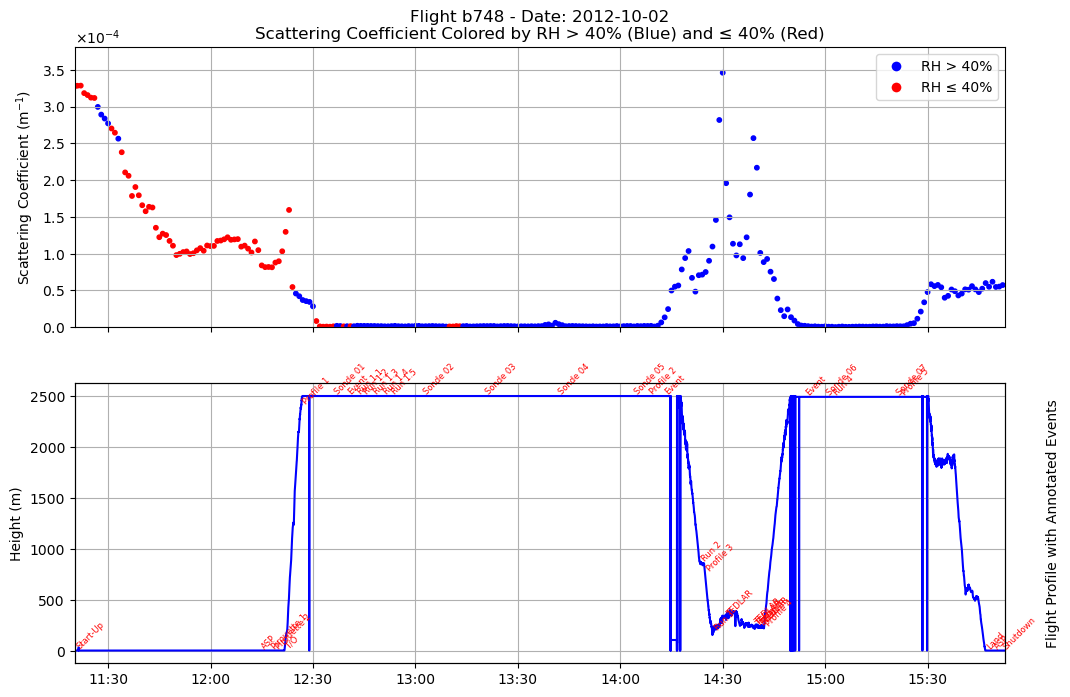

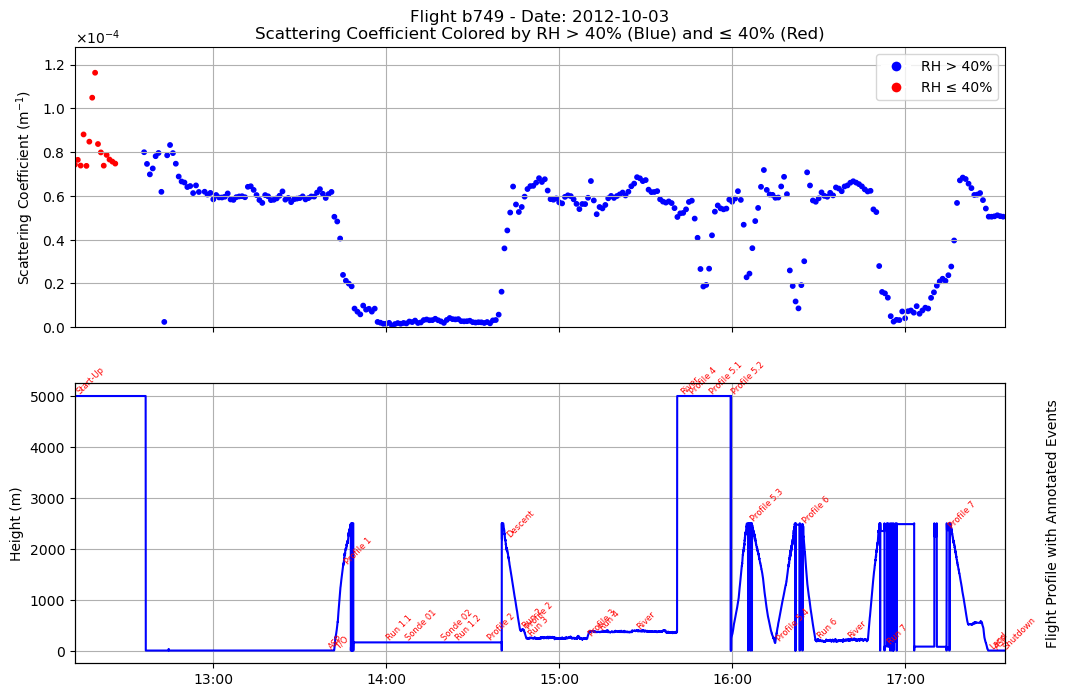

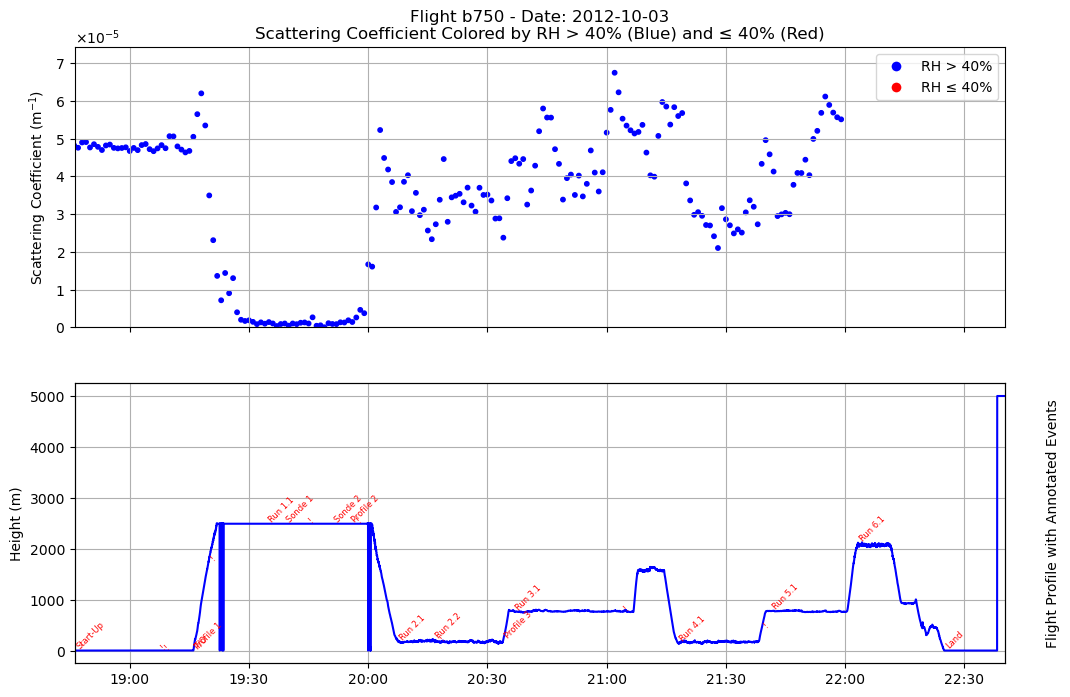

In [192]:
# List to store results
results = []



# Iterate over all matching flights
for nc_file, neph_file, flight_comments_file in zip(filtered_nc, filtered_neph,filtered_sum):

    #print(neph_file)
    ds_neph = dataset_neph(neph_file)
    ds_wet_neph = xr.open_dataset(nc_file)

    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', nc_file)
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"
    
    #print(flight_date)
    #Flight comments dataset
    df_flight = flight_comments_df(flight_comments_file)
    Resampled_sct, relativ_hum = relative_hum_calc(ds_neph,ds_wet_neph)

    plot_neph_data_v1( 
        flight_number=flight_number,
        flight_date = flight_date,
        scattering_resampled=Resampled_sct,
        RH=relativ_hum,
        ds_wet_neph=ds_wet_neph, 
        df_flight=df_flight)
    